In [3]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from itertools import cycle
from pathlib import Path
import random
import json
import seaborn as sns
import cv2
import sys
import glob


sys.path.append("../../../../donut/src/test/")
from common.config import cfg

import warnings

warnings.filterwarnings("ignore")

In [24]:
import cv2
import json
import numpy as np

def image_markable(annotation_path: str, image_path: str) -> np.array:
    '''
    Mark all the available information in the annotation.json on the corresponding image file.

    Params:
        annotation_path: the path of annotation file
        image_path: the path of the image file

    Return:
        numpy.ndarray (image with annotations)
    '''
    with open(annotation_path, "r") as f:
        annotation = json.load(f)

    # load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Unable to load image at {image_path}")
        return None

    print(f"✅ Image loaded: {image.shape}")

    # missing elements in annotation file
    missing_elements = []

    # ----------------------  mark main body of the image (plot-bb) ----------------------
    plot_bb = annotation.get("plot-bb")
    if plot_bb:
        # get the vertex to determine the boundary
        x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
        cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2)
    else:
        missing_elements.append("plot-bb")

    # ----------------------  mark tick location on x or y axes (ticks) ----------------------
    # use green dot to represent
    if "axes" in annotation:
        for axis in ["x-axis", "y-axis"]:
            if axis in annotation["axes"]:
                for tick in annotation["axes"][axis].get("ticks", []):
                    tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
                    cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1)
            else:
                missing_elements.append(f"{axis} ticks")
    else:
        missing_elements.append("axes")

    # ----------------------  mark the points location on line graph (data-series) ----------------------
    if "visual-elements" in annotation:
        elements = annotation["visual-elements"]

        # `lines` 
        # red dot
        if "lines" in elements and elements["lines"]:
            for line in elements["lines"]:
                for data_point in line:
                    x, y = int(data_point["x"]), int(data_point["y"])
                    cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 

        # `scatter points` 
        # light blue
        if "scatter points" in elements and elements["scatter points"]:
            for scatter in elements["scatter points"]:
                for point in scatter:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 0), -1) 

        # `bars`
        # light yellow
        if "bars" in elements and elements["bars"]:
            for bar in elements["bars"]:
                x0, y0 = int(bar["x0"]), int(bar["y0"])  
                width, height = int(bar["width"]), int(bar["height"])
                x1, y1 = x0 + width, y0 + height  
                cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 255), -1) 

        # `boxplots`
        if "boxplots" in elements and elements["boxplots"]:
            for box in elements["boxplots"]:
                x, y = int(box["x"]), int(box["y"])
                cv2.rectangle(image, (x - 5, y - 5), (x + 5, y + 5), (255, 0, 255), 2) 

        if "dot points" in elements and elements["dot points"]:
            for dot in elements["dot points"]:
                for point in dot:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 50), -1) 
    else:
        missing_elements.append("visual-elements")

    # ----------------------  `data-series` ----------------------
    if "data-series" in annotation:
        for series in annotation["data-series"]:
            x_value = series.get("x", "Unknown")
            y_value = series.get("y", "Unknown")
            # print(f"Data point: {x_value} -> {y_value}")
    else:
        missing_elements.append("data-series")

    # ---------------------- mark the text region (text) ----------------------
    # use purple frame to represent
    if "text" in annotation:
        for text_item in annotation["text"]:
            polygon = text_item.get("polygon")
            if polygon:
                x0, y0 = polygon["x0"], polygon["y0"]
                x2, y2 = polygon["x2"], polygon["y2"]
                cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2)
            else:
                missing_elements.append(f"text id {text_item.get('id', 'unknown')} missing polygon")
    else:
        missing_elements.append("text")

    # ---------------------- 5️⃣ output missing elements ----------------------
    if missing_elements:
        print("⚠️ Missing elements in annotation:", ", ".join(set(missing_elements)))

    return image

In [4]:
os.getcwd()

'/Users/yiding/personal_projects/ML/github_repo/donut/src/test/preprocess'

In [5]:
# list all image paths
image_dir = "../../../data/raw/train/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60578
['../../../data/raw/train/images/45df1fe3293b.jpg', '../../../data/raw/train/images/b2ab3b743d4e.jpg', '../../../data/raw/train/images/51d3b1a6baf3.jpg', '../../../data/raw/train/images/a9e9ce9277c1.jpg', '../../../data/raw/train/images/7f1f545fe081.jpg']


In [6]:
# list all annotation files paths

annotations_dir="../../../data/raw/train/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60578
['../../../data/raw/train/annotations/e91e28111e86.json', '../../../data/raw/train/annotations/75c0449f6917.json', '../../../data/raw/train/annotations/66dd2a250237.json', '../../../data/raw/train/annotations/58595c30beab.json', '../../../data/raw/train/annotations/497a547454d7.json']


In [15]:
# list all cropped image files

cropped_image_path = '../../../data/cropped_images/'
cropped_images_files = glob.glob(cropped_image_path + '*')
print(len(cropped_images_files))
print(cropped_images_files[:5])

60578
['../../../data/cropped_images/1be6b04cd997_vertical_bar.jpg', '../../../data/cropped_images/8af5a9652f71_line.jpg', '../../../data/cropped_images/ee2ad65504a3_line.jpg', '../../../data/cropped_images/ed4ebde8e0c5_line.jpg', '../../../data/cropped_images/cd8895162fc3_line.jpg']


In [17]:
# check the largets height and width in main boudary among all annotations

# initial value for height and width
height_max=0
width_max=0

for i in range(len(annotations_files)):
    with open(annotations_files[i], "r") as f:
        row = pd.json_normalize(json.load(f)).iloc[0]
        height_orig=row['plot-bb.height']
        width_orig=row['plot-bb.width']
        
        if height_orig>height_max:
            height_max=height_orig  
            a=annotations_files[i]
        if width_orig>width_max:
            width_max=width_orig
            b=annotations_files[i]

print(width_max)

print(height_max)
print(a)
print(b)

1657
1040
../../../data/raw/train/annotations/872d1be39bae.json
../../../data/raw/train/annotations/3ef41bbc82c3.json


In [18]:
# find strange graphs
# becauce the if cropped graph is strange, the blank part will be filled with zero (black)

def bad_cropped_filter(zeros:int,paths:list)->list:
    '''
    find all stanges cropped graphs
    
    parameters:
        zeros: the number of zeros in graph matrix, as a measurement
        paths: a list of graph paths
        
    return a list of graph paths
    '''
    stranges=[]
    for path in paths:
        image=Image.open(path)
        # count the numer of zeros in graph
        graph_zeros=np.array(image).size-np.count_nonzero(np.array(image))
        
        if graph_zeros>=zeros:
            stranges.append(path)
        else:
            continue
    
    return stranges

In [33]:
stranges=bad_cropped_filter(zeros=800000,paths=cropped_images_files)

In [34]:
stranges

['../../../data/cropped_images/872d1be39bae_line.jpg',
 '../../../data/cropped_images/3ef41bbc82c3_scatter.jpg',
 '../../../data/cropped_images/73cfbba65962_line.jpg']

In [22]:
search_string = "872d1be39bae"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/872d1be39bae.jpg']
['../../../data/raw/train/annotations/872d1be39bae.json']


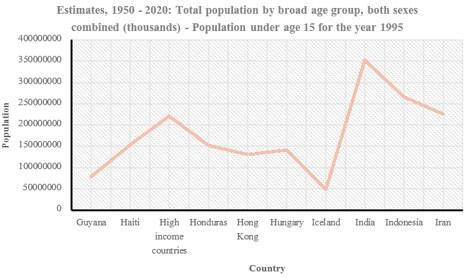

In [23]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (278, 470, 3)


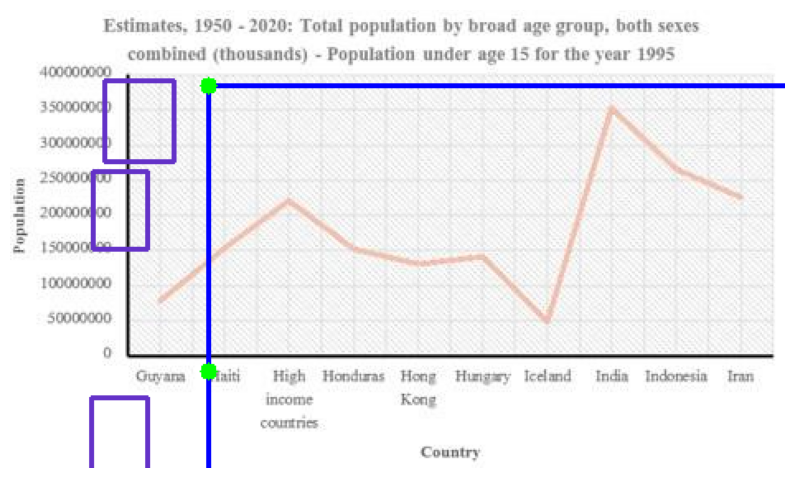

In [25]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

['../../../data/raw/train/images/3ef41bbc82c3.jpg']
['../../../data/raw/train/annotations/3ef41bbc82c3.json']


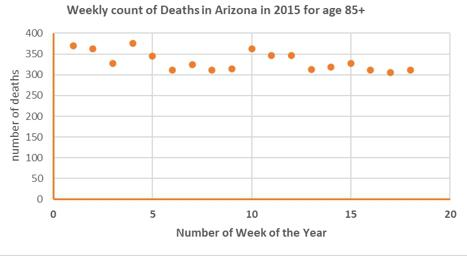

In [27]:
search_string = "3ef41bbc82c3"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)


Image.open(fp=matched_image_path[0])

✅ Image loaded: (256, 467, 3)


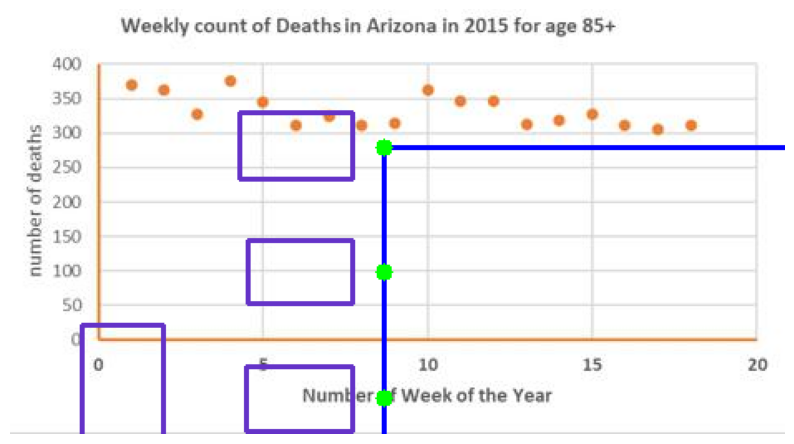

In [28]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

['../../../data/raw/train/images/73cfbba65962.jpg']
['../../../data/raw/train/annotations/73cfbba65962.json']


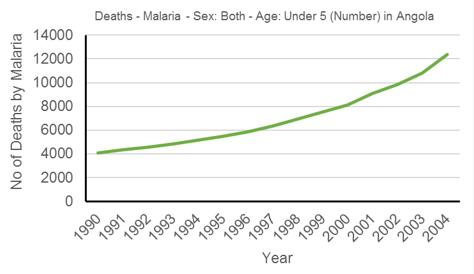

In [29]:
search_string = "73cfbba65962"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)


Image.open(fp=matched_image_path[0])

✅ Image loaded: (274, 474, 3)


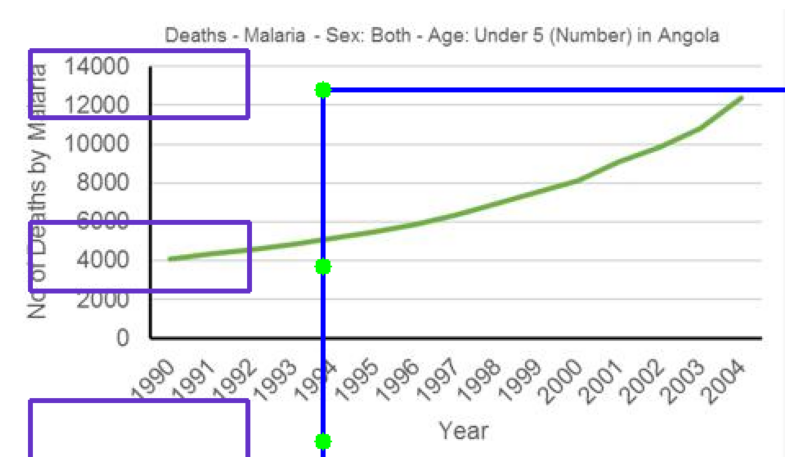

In [30]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()